# 02 - Data Cleaning

This notebook cleans the raw Online Retail II dataset and prepares it for exploratory data analysis and customer segmentation.


In [ ]:

import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

from src.utils.helpers import (
    print_header, print_subheader, load_data, 
    save_dataframe, save_json, get_dataframe_info
)

from src.data.preprocessing import (
    DataCleaner, validate_cleaned_data, get_cleaning_summary
)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)
np.random.seed(42)

print("Libraries loaded successfully")

Libraries loaded successfully


In [13]:
data_path = Path('../data/raw/online_retail_II.xlsx')
df_raw = load_data(str(data_path), sheet_name='Year 2009-2010')

original_shape = df_raw.shape

print(f"\nDataset shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"Memory usage: {df_raw.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

df_raw.head()

Loading dataset from: ..\data\raw\online_retail_II.xlsx
Sheet: Year 2009-2010

✓ Dataset loaded successfully!
  Shape: 525,461 rows × 8 columns
  Memory: 102.33 MB


Dataset shape: 525,461 rows × 8 columns
Memory usage: 102.33 MB


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom


In [14]:
print("Data Quality Check - Before Cleaning\n")

missing_before = df_raw.isnull().sum()
missing_before = missing_before[missing_before > 0]
print("Missing values:")
print(missing_before)

print(f"\nMissing Customer ID: {df_raw['Customer ID'].isnull().sum():,} ({df_raw['Customer ID'].isnull().sum()/len(df_raw)*100:.2f}%)")
print(f"Cancelled Transactions: {df_raw[df_raw['Invoice'].astype(str).str.startswith('C', na=False)].shape[0]:,}")
print(f"Negative Quantities: {(df_raw['Quantity'] < 0).sum():,}")
print(f"Zero Quantities: {(df_raw['Quantity'] == 0).sum():,}")
print(f"Invalid Prices (≤0): {(df_raw['Price'] <= 0).sum():,}")
print(f"Duplicate Records: {df_raw.duplicated().sum():,}")

df_raw[['Quantity', 'Price']].describe()

Data Quality Check - Before Cleaning

Missing values:
Description      2928
Customer ID    107927
dtype: int64

Missing Customer ID: 107,927 (20.54%)
Cancelled Transactions: 10,206
Negative Quantities: 12,326
Zero Quantities: 0
Invalid Prices (≤0): 3,690
Duplicate Records: 6,865


,Quantity,Price
count,525461.00,525461.00
mean,10.34,4.69
std,107.42,146.13
min,-9600.00,-53594.36
25%,1.00,1.25
50%,3.00,2.10
75%,10.00,4.21
max,19152.00,25111.09


In [15]:
cleaner = DataCleaner(verbose=True)

df_cleaned = cleaner.clean_data(df_raw, remove_outliers=False)

cleaning_report = cleaner.get_cleaning_report()

Remove missing Customer ID: 525,461 -> 417,534
Remove cancelled transactions: 417,534 -> 407,695
Remove invalid quantities: 407,695 -> 407,695
Remove invalid prices: 407,695 -> 407,664
Remove duplicates: 407,664 -> 400,916


In [16]:
print("Shape Comparison:")
print(f"Before: {original_shape[0]:,} rows × {original_shape[1]} columns")
print(f"After:  {df_cleaned.shape[0]:,} rows × {df_cleaned.shape[1]} columns")
print(f"Removed: {original_shape[0] - df_cleaned.shape[0]:,} rows")
print(f"Retention: {df_cleaned.shape[0]/original_shape[0]*100:.2f}%")

df_cleaned.head(10)

Shape Comparison:
Before: 525,461 rows × 8 columns
After:  400,916 rows × 9 columns
Removed: 124,545 rows
Retention: 76.30%


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom,83.40
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom,81.00
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom,81.00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom,100.80
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom,30.00
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.00,United Kingdom,39.60
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom,30.00
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.00,United Kingdom,59.50
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.00,United Kingdom,30.60
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.00,United Kingdom,45.00


In [17]:
validation_results = validate_cleaned_data(df_cleaned)

print("Validation Results:")
for check, result in validation_results.items():
    status = "✓" if result else "✗"
    print(f"{status} {check.replace('_', ' ').title()}")

if validation_results['all_checks_passed']:
    print("\nAll validation checks passed!")


Validation Results:
✓ Has Customer Id
✓ Positive Quantities
✓ Positive Prices
✓ No Cancelled Invoices
✓ Has Revenue
✓ No Duplicates
✓ No Missing Values
✓ All Checks Passed

All validation checks passed!


In [18]:
print("Data Quality - After Cleaning\n")

missing_after = df_cleaned.isnull().sum()
if missing_after.sum() == 0:
    print("No missing values found")
else:
    print(missing_after[missing_after > 0])

print(f"\nAll Customer IDs present: {df_cleaned['Customer ID'].notna().all()}")
print(f"All Quantities positive: {(df_cleaned['Quantity'] > 0).all()}")
print(f"All Prices positive: {(df_cleaned['Price'] > 0).all()}")
print(f"No cancelled transactions: {not df_cleaned['Invoice'].astype(str).str.startswith('C').any()}")

print("\nRevenue Statistics:")
print(f"Total Revenue: £{df_cleaned['Revenue'].sum():,.2f}")
print(f"Average Revenue: £{df_cleaned['Revenue'].mean():.2f}")
print(f"Median Revenue: £{df_cleaned['Revenue'].median():.2f}")

df_cleaned[['Quantity', 'Price', 'Revenue']].describe()

Data Quality - After Cleaning

No missing values found

All Customer IDs present: True
All Quantities positive: True
All Prices positive: True
No cancelled transactions: True

Revenue Statistics:
Total Revenue: £8,798,233.74
Average Revenue: £21.95
Median Revenue: £12.50


,Quantity,Price,Revenue
count,400916.00,400916.00,400916.00
mean,13.77,3.31,21.95
std,97.64,35.05,77.76
min,1.00,0.00,0.00
25%,2.00,1.25,5.00
50%,5.00,1.95,12.50
75%,12.00,3.75,19.50
max,19152.00,10953.50,15818.40


In [19]:
comparison_df = get_cleaning_summary(df_raw, df_cleaned)
comparison_df

,Metric,Before,After
0,Rows,525461,400916
1,Columns,8,9
2,Unique Customers,4383,4312
3,Unique Products,4632,4017
4,Unique Invoices,28816,19213
5,Missing Values,110855,0
6,Duplicates,6865,0


In [21]:
comparison_data = {
    'Metric': [
        'Total Rows',
        'Total Columns',
        'Unique Customers',
        'Unique Products',
        'Unique Invoices',
        'Date Range (days)',
        'Missing Values',
        'Duplicates'
    ],
    'Before_Cleaning': [
        len(df_raw),
        len(df_raw.columns),
        df_raw['Customer ID'].nunique(),
        df_raw['StockCode'].nunique(),
        df_raw['Invoice'].nunique(),
        (df_raw['InvoiceDate'].max() - df_raw['InvoiceDate'].min()).days,
        df_raw.isnull().sum().sum(),
        df_raw.duplicated().sum()
    ],
    'After_Cleaning': [
        len(df_cleaned),
        len(df_cleaned.columns),
        df_cleaned['Customer ID'].nunique(),
        df_cleaned['StockCode'].nunique(),
        df_cleaned['Invoice'].nunique(),
        (df_cleaned['InvoiceDate'].max() - df_cleaned['InvoiceDate'].min()).days,
        df_cleaned.isnull().sum().sum(),
        df_cleaned.duplicated().sum()
    ]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df['Change'] = comparison_df['After_Cleaning'] - comparison_df['Before_Cleaning']
comparison_df['Change_Pct'] = round((comparison_df['Change'] / comparison_df['Before_Cleaning']) * 100, 2)

comparison_df

,Metric,Before_Cleaning,After_Cleaning,Change,Change_Pct
0,Total Rows,525461,400916,-124545,-23.70
1,Total Columns,8,9,1,12.50
2,Unique Customers,4383,4312,-71,-1.62
3,Unique Products,4632,4017,-615,-13.28
4,Unique Invoices,28816,19213,-9603,-33.33
5,Date Range (days),373,373,0,0.00
6,Missing Values,110855,0,-110855,-100.00
7,Duplicates,6865,0,-6865,-100.00


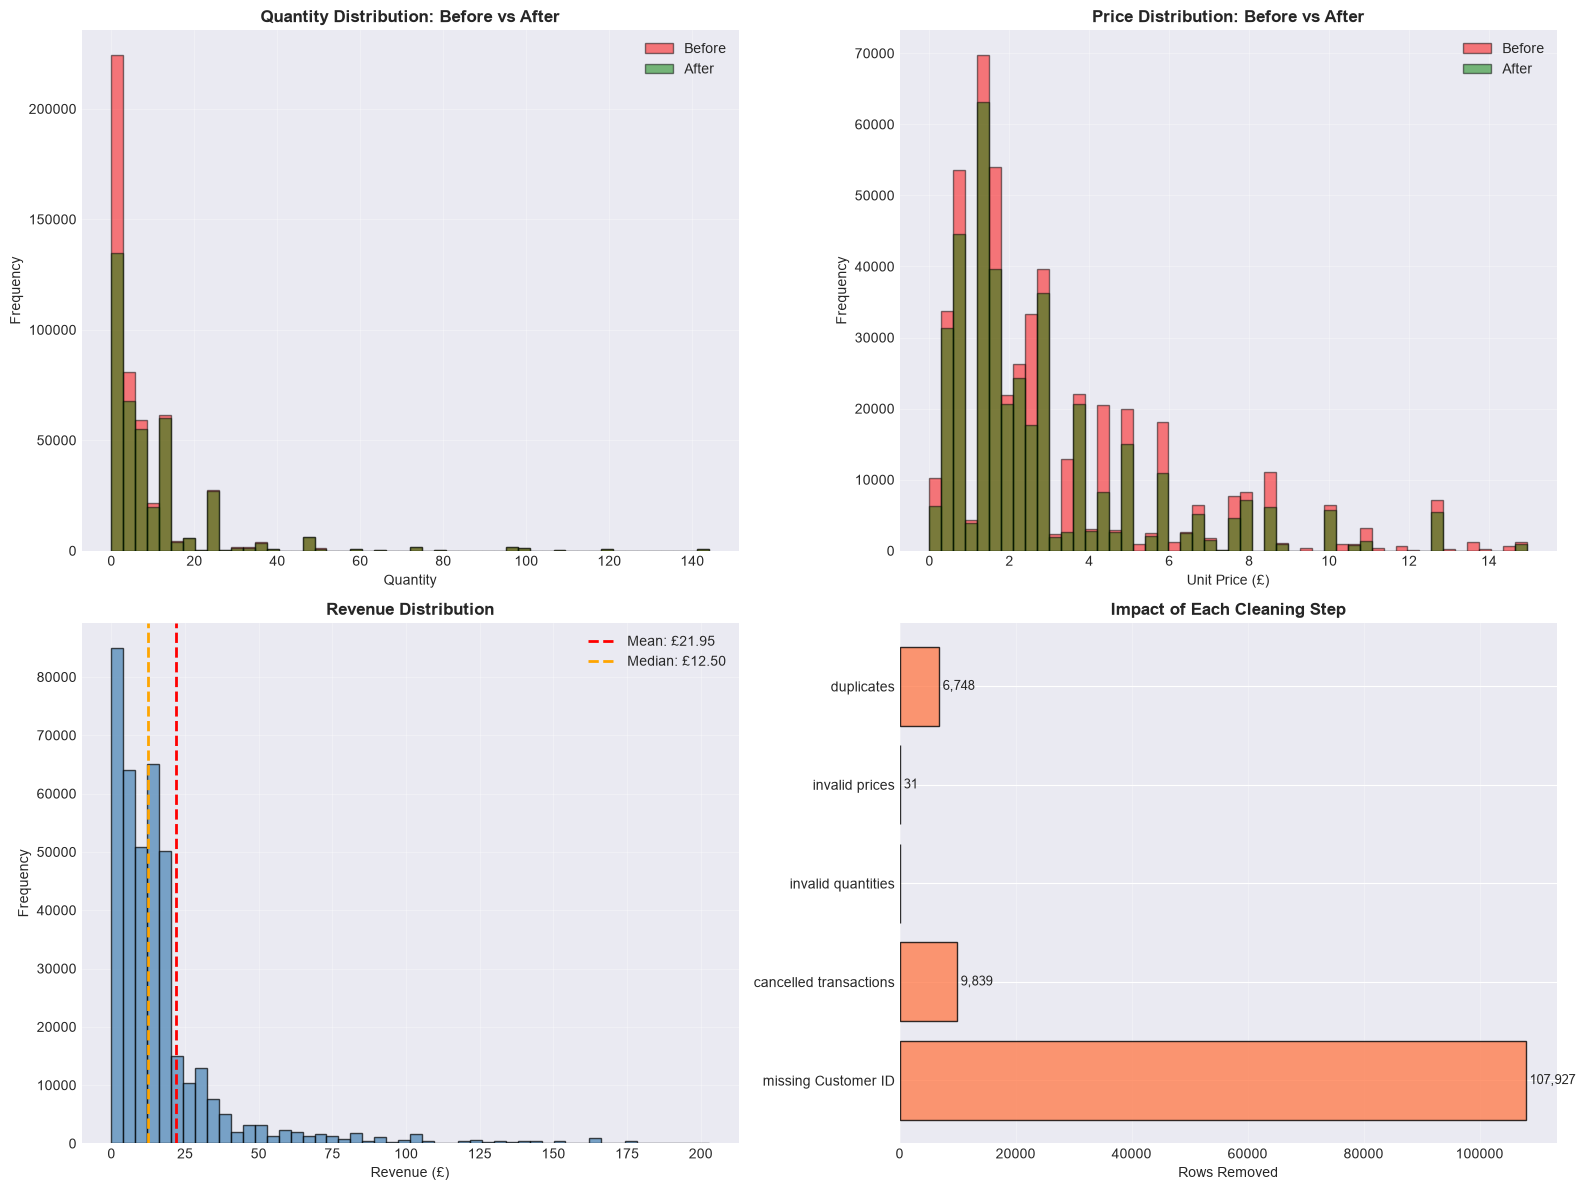

In [ ]:

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

q99_qty = df_cleaned['Quantity'].quantile(0.99)
axes[0, 0].hist(df_raw['Quantity'], bins=50, alpha=0.5, label='Before', 
                color='red', edgecolor='black', range=(0, q99_qty))
axes[0, 0].hist(df_cleaned['Quantity'], bins=50, alpha=0.5, label='After', 
                color='green', edgecolor='black', range=(0, q99_qty))
axes[0, 0].set_xlabel('Quantity')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Quantity Distribution: Before vs After', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

q99_price = df_cleaned['Price'].quantile(0.99)
axes[0, 1].hist(df_raw['Price'], bins=50, alpha=0.5, label='Before', 
                color='red', edgecolor='black', range=(0, q99_price))
axes[0, 1].hist(df_cleaned['Price'], bins=50, alpha=0.5, label='After', 
                color='green', edgecolor='black', range=(0, q99_price))
axes[0, 1].set_xlabel('Unit Price (£)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Price Distribution: Before vs After', fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

q99_revenue = df_cleaned['Revenue'].quantile(0.99)
axes[1, 0].hist(df_cleaned['Revenue'], bins=50, color='steelblue', 
                alpha=0.7, edgecolor='black', range=(0, q99_revenue))
axes[1, 0].set_xlabel('Revenue (£)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Revenue Distribution', fontweight='bold')
axes[1, 0].axvline(df_cleaned['Revenue'].mean(), color='red', linestyle='--', 
                   linewidth=2, label=f'Mean: £{df_cleaned["Revenue"].mean():.2f}')
axes[1, 0].axvline(df_cleaned['Revenue'].median(), color='orange', linestyle='--', 
                   linewidth=2, label=f'Median: £{df_cleaned["Revenue"].median():.2f}')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

step_names = [step['step'] for step in cleaning_report['steps']]
rows_removed = [step['rows_removed'] for step in cleaning_report['steps']]
step_names_short = [name.replace('Remove ', '').replace('Transactions', 'Trans') 
                    for name in step_names]

axes[1, 1].barh(step_names_short, rows_removed, color='coral', 
                alpha=0.8, edgecolor='black')
axes[1, 1].set_xlabel('Rows Removed')
axes[1, 1].set_title('Impact of Each Cleaning Step', fontweight='bold')
axes[1, 1].grid(axis='x', alpha=0.3)

for i, v in enumerate(rows_removed):
    if v > 0:
        axes[1, 1].text(v, i, f' {v:,}', va='center', fontsize=9)

plt.tight_layout()
fig_path = figures_dir / 'cleaning_impact.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()

In [23]:
steps_df = pd.DataFrame(cleaning_report['steps'])
steps_df

,step,rows_before,rows_after,rows_removed
0,Remove missing Customer ID,525461,417534,107927
1,Remove cancelled transactions,417534,407695,9839
2,Remove invalid quantities,407695,407695,0
3,Remove invalid prices,407695,407664,31
4,Remove duplicates,407664,400916,6748


In [25]:
Path('../data/processed').mkdir(parents=True, exist_ok=True)

output_path = '../data/processed/cleaned_transactions.csv'
save_dataframe(df_cleaned, output_path, file_format='csv')

print(f"Cleaned dataset saved: {output_path}")
print(f"Shape: {df_cleaned.shape[0]:,} rows × {df_cleaned.shape[1]} columns")

try:
    parquet_path = '../data/processed/cleaned_transactions.parquet'
    df_cleaned.to_parquet(parquet_path, index=False)
    print(f"Also saved as parquet: {parquet_path}")
except:
    print("Parquet save skipped")

✓ Data saved to: ../data/processed/cleaned_transactions.csv
  File size: 52.08 MB
Cleaned dataset saved: ../data/processed/cleaned_transactions.csv
Shape: 400,916 rows × 9 columns
Parquet save skipped


In [26]:
cleaner.save_cleaning_report('../reports/cleaning_report.json')

summary_report = {
    'cleaning_date': pd.Timestamp.now().isoformat(),
    'input_file': 'data/raw/online_retail_II.xlsx',
    'output_file': 'data/processed/cleaned_transactions.csv',
    'original_shape': {
        'rows': int(cleaning_report['initial_shape'][0]),
        'columns': int(cleaning_report['initial_shape'][1])
    },
    'cleaned_shape': {
        'rows': int(cleaning_report['final_shape'][0]),
        'columns': int(cleaning_report['final_shape'][1])
    },
    'rows_removed': int(cleaning_report['initial_shape'][0] - cleaning_report['final_shape'][0]),
    'retention_percentage': round((cleaning_report['final_shape'][0] / cleaning_report['initial_shape'][0]) * 100, 2),
    'new_features': ['Revenue'],
    'validation_passed': validation_results['all_checks_passed'],
    'statistics': {
        'unique_customers': int(df_cleaned['Customer ID'].nunique()),
        'unique_products': int(df_cleaned['StockCode'].nunique()),
        'unique_invoices': int(df_cleaned['Invoice'].nunique()),
        'total_revenue': float(df_cleaned['Revenue'].sum()),
        'date_range': {
            'start': str(df_cleaned['InvoiceDate'].min()),
            'end': str(df_cleaned['InvoiceDate'].max()),
            'days': int((df_cleaned['InvoiceDate'].max() - df_cleaned['InvoiceDate'].min()).days)
        }
    }
}

save_json(summary_report, '../reports/cleaning_summary.json')
print("Reports saved")

✓ JSON saved to: ../reports/cleaning_summary.json
Reports saved


In [27]:
print("Final Dataset Overview\n")
print(f"Shape: {len(df_cleaned):,} rows × {len(df_cleaned.columns)} columns")
print(f"Memory: {df_cleaned.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\nColumns:")
for i, col in enumerate(df_cleaned.columns, 1):
    print(f"{i}. {col} ({df_cleaned[col].dtype})")

print(f"\nDate Range: {df_cleaned['InvoiceDate'].min()} to {df_cleaned['InvoiceDate'].max()}")
print(f"Duration: {(df_cleaned['InvoiceDate'].max() - df_cleaned['InvoiceDate'].min()).days} days")

print(f"\nUnique Customers: {df_cleaned['Customer ID'].nunique():,}")
print(f"Unique Products: {df_cleaned['StockCode'].nunique():,}")
print(f"Unique Invoices: {df_cleaned['Invoice'].nunique():,}")
print(f"Total Revenue: £{df_cleaned['Revenue'].sum():,.2f}")

print("\nTop 5 Countries by Revenue:")
top_countries = df_cleaned.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head()
for country, revenue in top_countries.items():
    print(f"{country}: £{revenue:,.2f}")

Final Dataset Overview

Shape: 400,916 rows × 9 columns
Memory: 84.06 MB

Columns:
1. Invoice (object)
2. StockCode (object)
3. Description (object)
4. Quantity (int64)
5. InvoiceDate (datetime64[us])
6. Price (float64)
7. Customer ID (float64)
8. Country (str)
9. Revenue (float64)

Date Range: 2009-12-01 07:45:00 to 2010-12-09 20:01:00
Duration: 373 days

Unique Customers: 4,312
Unique Products: 4,017
Unique Invoices: 19,213
Total Revenue: £8,798,233.74

Top 5 Countries by Revenue:
United Kingdom: £7,381,644.43
EIRE: £356,041.86
Netherlands: £268,784.35
Germany: £202,025.39
France: £146,107.07


In [28]:
total_removed = cleaning_report['initial_shape'][0] - cleaning_report['final_shape'][0]
retention = (cleaning_report['final_shape'][0] / cleaning_report['initial_shape'][0]) * 100

print(f"Original records: {cleaning_report['initial_shape'][0]:,}")
print(f"Cleaned records: {cleaning_report['final_shape'][0]:,}")
print(f"Records removed: {total_removed:,}")
print(f"Retention rate: {retention:.2f}%")
print(f"\nNew feature created: Revenue = Quantity × Price")
print(f"Total revenue: £{df_cleaned['Revenue'].sum():,.2f}")
print("\nData cleaning complete - ready for EDA")

Original records: 525,461
Cleaned records: 400,916
Records removed: 124,545
Retention rate: 76.30%

New feature created: Revenue = Quantity × Price
Total revenue: £8,798,233.74

Data cleaning complete - ready for EDA
